# BÀI TẬP: TITANIC
**Nguồn:** kaggle.com/c/titanic (891 dòng)


In [13]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [14]:
# TODO
print("Data size: ",df.shape)
print("Data column: ", df.columns)
print("Data types:\n",df.dtypes)

Data size:  (891, 15)
Data column:  Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')
Data types:
 survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class              str
who                str
adult_male        bool
deck               str
embark_town        str
alive              str
alone             bool
dtype: object


## A.2. Missing values & Duplicate data

In [15]:
# TODO
print(df.isnull().sum())
print("-------------------")
print(df.duplicated().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
-------------------
107


## A.3. Invalid values

In [16]:
# TODO
df.nunique()

survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64

## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [17]:
# TODO
df['family_size'] = df['sibsp'] + df['parch'] + 1

df


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [18]:
# TODO
df.mean(numeric_only=True)

survived        0.383838
pclass          2.308642
age            29.699118
sibsp           0.523008
parch           0.381594
fare           32.204208
adult_male      0.602694
alone           0.602694
family_size     1.904602
dtype: float64

In [19]:
df.median(numeric_only=True)

survived        0.0000
pclass          3.0000
age            28.0000
sibsp           0.0000
parch           0.0000
fare           14.4542
adult_male      1.0000
alone           1.0000
family_size     1.0000
dtype: float64

In [20]:
df.mode()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,24.0,0,0,8.05,S,Third,man,True,C,Southampton,no,True,1


## Group 2 — Dispersion

In [21]:
# TODO
numeric_cols = ['age', 'sibsp', 'parch', 'fare', 'family_size']

print("Range:")
print(df[numeric_cols].max() - df[numeric_cols].min())

print("\nVariance:")
print(df[numeric_cols].var())

print("\nStandard Deviation:")
print(df[numeric_cols].std())

print("\nIQR:")
print(df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25))

Range:
age             79.5800
sibsp            8.0000
parch            6.0000
fare           512.3292
family_size     10.0000
dtype: float64

Variance:
age             211.019125
sibsp             1.216043
parch             0.649728
fare           2469.436846
family_size       2.603248
dtype: float64

Standard Deviation:
age            14.526497
sibsp           1.102743
parch           0.806057
fare           49.693429
family_size     1.613459
dtype: float64

IQR:
age            17.8750
sibsp           1.0000
parch           0.0000
fare           23.0896
family_size     1.0000
dtype: float64


## Group 3 — Location and Shape

Q1 (25%):
age            20.1250
sibsp           0.0000
parch           0.0000
fare            7.9104
family_size     1.0000
Name: 0.25, dtype: float64

Q2 (50%):
age            28.0000
sibsp           0.0000
parch           0.0000
fare           14.4542
family_size     1.0000
Name: 0.5, dtype: float64

Q3 (75%):
age            38.0
sibsp           1.0
parch           0.0
fare           31.0
family_size     2.0
Name: 0.75, dtype: float64

Skewness:
age            0.389108
sibsp          3.695352
parch          2.749117
fare           4.787317
family_size    2.727441
dtype: float64

Kurtosis:
age             0.178274
sibsp          17.880420
parch           9.778125
fare           33.398141
family_size     9.159666
dtype: float64


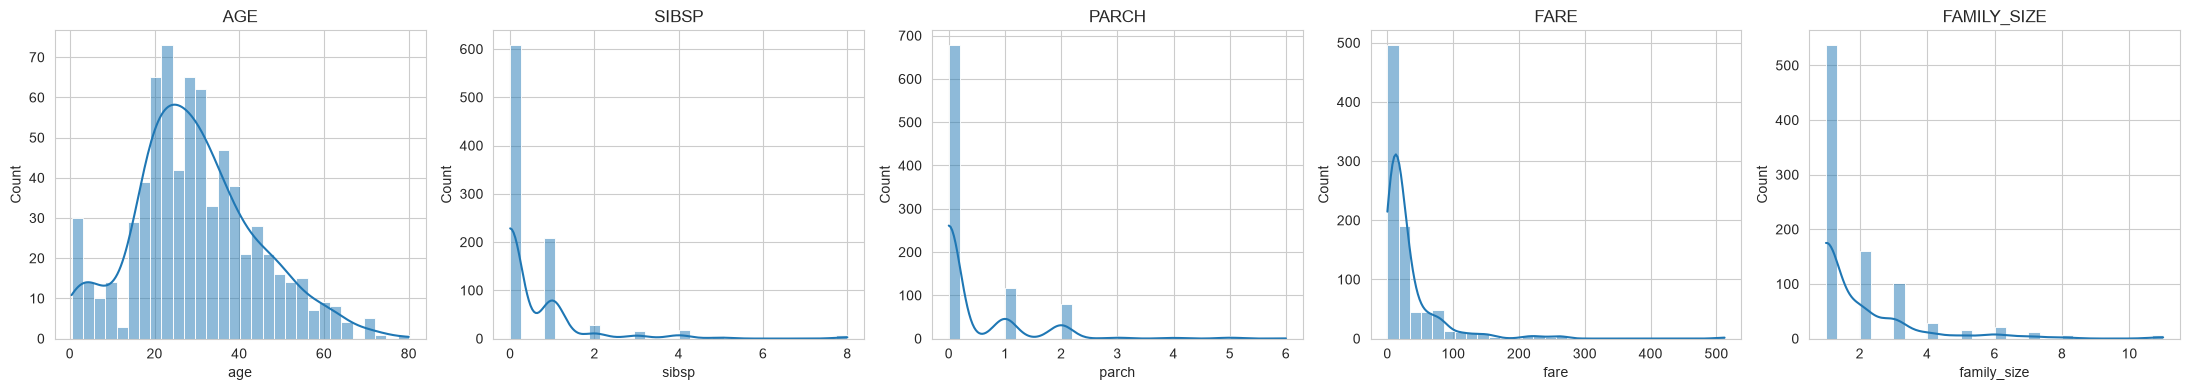

In [22]:
# TODO
numeric_cols = ['age', 'sibsp', 'parch', 'fare', 'family_size']

print("Q1 (25%):")
print(df[numeric_cols].quantile(0.25))

print("\nQ2 (50%):")
print(df[numeric_cols].quantile(0.50))

print("\nQ3 (75%):")
print(df[numeric_cols].quantile(0.75))

print("\nSkewness:")
print(df[numeric_cols].skew())

print("\nKurtosis:")
print(df[numeric_cols].kurt())

numeric_cols = ['age', 'sibsp', 'parch', 'fare', 'family_size']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(col.upper())
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

Tỷ lệ sống sót theo hạng vé (%):
class
First     62.962963
Second    47.282609
Third     24.236253
Name: survived, dtype: float64

Hạng vé có tỷ lệ sống sót cao nhất: First
Hạng vé có tỷ lệ sống sót thấp nhất: Third
Chênh lệch: 38.73 điểm %


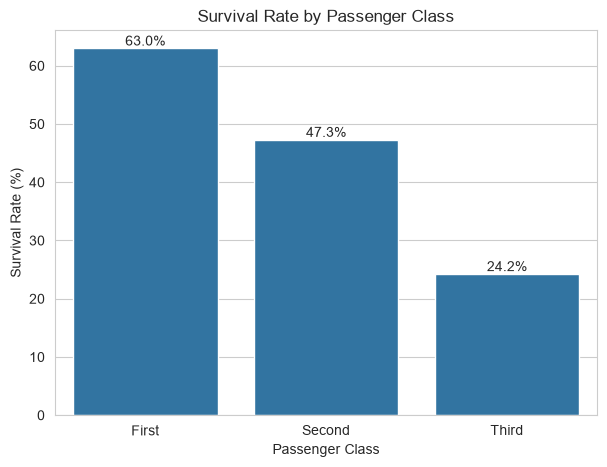

In [23]:
# TODO
class_survival = (df.groupby('class')['survived'].mean().mul(100).sort_values(ascending=False))

print("Tỷ lệ sống sót theo hạng vé (%):")
print(class_survival)

highest_class = class_survival.idxmax()
lowest_class = class_survival.idxmin()
difference = class_survival.max() - class_survival.min()

print("\nHạng vé có tỷ lệ sống sót cao nhất:", highest_class)
print("Hạng vé có tỷ lệ sống sót thấp nhất:", lowest_class)
print("Chênh lệch:", round(difference, 2), "điểm %")

class_plot = class_survival.reset_index()
class_plot.columns = ['class', 'SurvivalRate']

plt.figure(figsize=(7, 5))

ax = sns.barplot(data=class_plot, x='class', y='SurvivalRate')

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')

for container in ax.containers: ax.bar_label(container, fmt='%.1f%%')
plt.show()


## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

Tỷ lệ sống sót theo giới tính (%):
sex
female    74.203822
male      18.890815
Name: survived, dtype: float64

Tỷ lệ sống sót theo hạng vé (%):
class
First     62.962963
Second    47.282609
Third     24.236253
Name: survived, dtype: float64

Chênh lệch theo giới tính: 55.31 điểm %
Chênh lệch theo hạng vé: 38.73 điểm %
=> Giới tính ảnh hưởng đến tỷ lệ sống sót mạnh hơn.


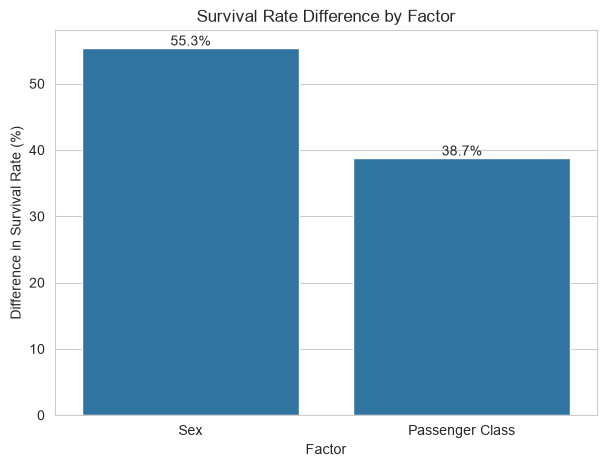

In [24]:
# TODO
sex_survival = df.groupby('sex')['survived'].mean() * 100
class_survival = df.groupby('class')['survived'].mean() * 100
sex_gap = sex_survival.max() - sex_survival.min()
class_gap = class_survival.max() - class_survival.min()

print("Tỷ lệ sống sót theo giới tính (%):")
print(sex_survival)

print("\nTỷ lệ sống sót theo hạng vé (%):")
print(class_survival)

print("\nChênh lệch theo giới tính:", round(sex_gap, 2), "điểm %")
print("Chênh lệch theo hạng vé:", round(class_gap, 2), "điểm %")

if sex_gap > class_gap:
    print("=> Giới tính ảnh hưởng đến tỷ lệ sống sót mạnh hơn.")
else:
    print("=> Hạng vé ảnh hưởng đến tỷ lệ sống sót mạnh hơn.")

comparison = pd.DataFrame({'Factor': ['Sex', 'Passenger Class'], 'Difference': [sex_gap, class_gap]})

plt.figure(figsize=(7, 5))

ax = sns.barplot(data=comparison, x='Factor', y='Difference')

plt.title('Survival Rate Difference by Factor')
plt.xlabel('Factor')
plt.ylabel('Difference in Survival Rate (%)')

for container in ax.containers: ax.bar_label(container, fmt='%.1f%%')
plt.show()

## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

Giá vé trung bình:
survived
0    22.117887
1    48.395408
Name: fare, dtype: float64

Không sống: 22.12
Sống sót: 48.4


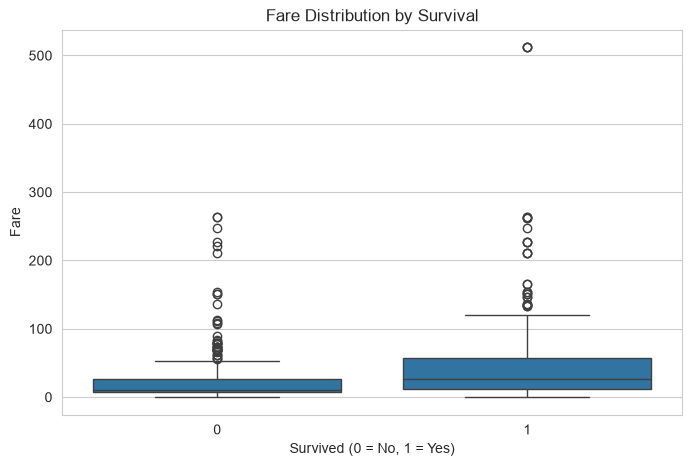

In [25]:
# TODO
fare_survival = df.groupby('survived')['fare'].mean()

print("Giá vé trung bình:")
print(fare_survival)

print("\nKhông sống:", round(fare_survival[0], 2))
print("Sống sót:", round(fare_survival[1], 2))

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='survived', y='fare')

plt.title('Fare Distribution by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')
plt.show()

## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

   family_size  count  SurvivalRate
0            1    537     30.353818
1            2    161     55.279503
2            3    102     57.843137
3            4     29     72.413793
4            5     15     20.000000
5            6     22     13.636364
6            7     12     33.333333
7            8      6      0.000000
8           11      7      0.000000


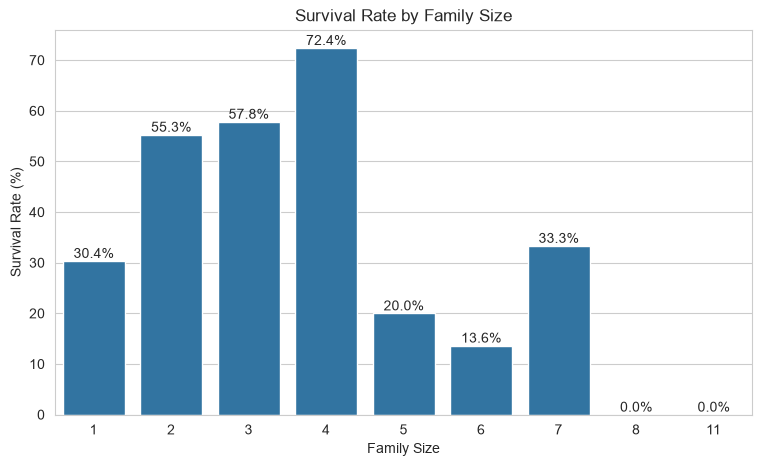

In [26]:
# TODO
family_survival = (df.groupby('family_size')['survived'].agg(['count', 'mean']).reset_index())

family_survival['SurvivalRate'] = family_survival['mean'] * 100

print(family_survival[['family_size', 'count', 'SurvivalRate']])

plt.figure(figsize=(9, 5))

ax = sns.barplot(data=family_survival, x='family_size', y='SurvivalRate')

plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate (%)')

for container in ax.containers: ax.bar_label(container, fmt='%.1f%%')

plt.show()

## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

Tỷ lệ sống sót theo cảng lên tàu (%):
embark_town
Cherbourg      55.357143
Queenstown     38.961039
Southampton    33.695652
Name: survived, dtype: float64

Cảng có tỷ lệ sống sót cao nhất: Cherbourg
Tỷ lệ sống sót: 55.36 %


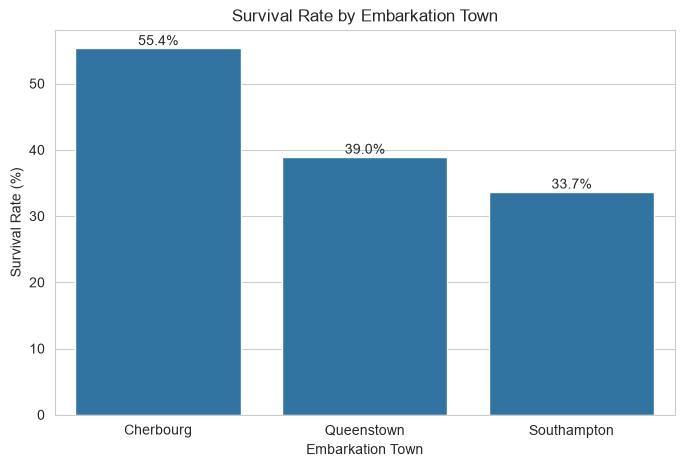

In [27]:
# TODO
town_survival = (df.groupby('embark_town')['survived'].mean().mul(100).sort_values(ascending=False))

print("Tỷ lệ sống sót theo cảng lên tàu (%):")
print(town_survival)

print("\nCảng có tỷ lệ sống sót cao nhất:", town_survival.idxmax())
print("Tỷ lệ sống sót:", round(town_survival.max(), 2), "%")

town_plot = town_survival.reset_index()
town_plot.columns = ['embark_town', 'SurvivalRate']

plt.figure(figsize=(8, 5))

ax = sns.barplot(data=town_plot, x='embark_town', y='SurvivalRate')

plt.title('Survival Rate by Embarkation Town')
plt.xlabel('Embarkation Town')
plt.ylabel('Survival Rate (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

*(Viết insight của bạn vào đây...)*
## Phần A – Data Profiling:
* Dữ liệu Titanic có một số giá trị thiếu, đặc biệt ở các cột như `age` và `deck`, vì vậy cần lưu ý khi phân tích các biến này. Cột `family_size = sibsp + parch + 1` giúp thể hiện rõ hơn quy mô gia đình của mỗi hành khách.

## Phần B – Descriptive Statistics:
* Tuổi và giá vé (`fare`) có độ phân tán khá lớn, trong đó `fare` có phân phối lệch phải do tồn tại một số hành khách mua vé có giá rất cao. Phần lớn hành khách đi một mình hoặc trong các nhóm gia đình nhỏ.

## Phần C – Giới tính và hạng vé:
* Tỷ lệ sống sót khác biệt rõ rệt giữa các nhóm; hành khách nữ có tỷ lệ sống cao hơn nam và hành khách hạng First có tỷ lệ sống cao hơn hạng Second và Third. Điều này cho thấy giới tính và hạng vé có liên hệ mạnh với khả năng sống sót.

* Giá vé và quy mô gia đình: Nhóm có giá vé cao thường có tỷ lệ sống sót cao hơn, tuy nhiên không thể khẳng định giá vé là nguyên nhân trực tiếp vì nó có liên quan đến hạng vé. Quy mô gia đình cũng có ảnh hưởng, khi các gia đình nhỏ có xu hướng sống sót tốt hơn so với người đi một mình hoặc nhóm gia đình quá đông.

* Cảng lên tàu: Tỷ lệ sống sót không đồng đều giữa các cảng lên tàu; một số cảng có tỷ lệ sống cao hơn đáng kể. Sự khác biệt này có thể liên quan đến cơ cấu hành khách về giới tính, hạng vé và giá vé tại từng cảng.
